---
# Sustainability Aware Asset Management
## Group S — EM region | Scope 1 + Scope 2 emissions

- **Part 1**: The first part loads the data, cleans it, and performs initial portfolio tests (minimum variance and value-weighted)
- **Part 2**: The second part incorporates carbon emissions and builds portfolios with emissions constraints

*Code description : For the code, run the cells in order and place the data files in a “Data” folder within the same directory as the notebook*

---

### 0. Importing libraries, graph settings and constants


In [1]:
# === Standard library ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize

# === Plot settings ===
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.4,
    "font.size": 11,})

# === Constants for the project ===
DATA_DIR        = Path("Data")
OUTPUT_DIR_CSV  = Path("Results/Numerics")
OUTPUT_DIR_PLOT = Path("Results/Plots")
REGION          = "EM"
REB_YEARS       = list(range(2013, 2025))
MIN_OBS         = 36
STALE_THRESHOLD = 0.50
RI_MIN          = 0.50
THETA_NZ        = 0.10
V0              = 1_000_000

# === Create output directories if they do not exist ===
# All figures are saved to Results/Plots and all numerical outputs to Results/Numerics. These folders are created automatically so the notebook runs without prior setup.
OUTPUT_DIR_CSV.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR_PLOT.mkdir(parents=True, exist_ok=True)

---
# Part 1)
---
## 1. Data Loading & Cleaning
---

### 1.1 Firms used for the project
In this section, we first load the list of firms provided to us. We then sort this list and retain only the companies located in the region of interest, namely emerging markets (EM).

In [2]:
# Load the firms data from the Excel file
firms = pd.read_excel(DATA_DIR / "Static_2025.xlsx")

# Cleaning the data with removing rows with missing ISIN and strip whitespace from 'Region' column
firms = firms.dropna(subset=["ISIN"]).copy()
firms["Region"] = firms["Region"].astype(str).str.strip()

# Set ISIN as the index
firms = firms.set_index("ISIN")

# Keep only Emerging Markets firms
firms = firms[firms["Region"] == REGION]

print(f"Number of {REGION} firms: {len(firms)}")
display(firms.head())

Number of EM firms: 702


,NAME,Country,Region
ISIN,,,
ARALUA010258,ALUAR,AR,EM
ARP125991090,BANCO BBVA ARGENTINA,AR,EM
ARSIDE010029,TERNIUM ARGENTINA SOCIEDAD ANONIMA,AR,EM
BMG211591018,CHINA YURUN FOOD GROUP,CN,EM
BRABEVACNOR1,AMBEV ON,BR,EM


---
### 1.2 Data import
We then import the time-series data.We distinguish between two types of time series:

- Monthly  
- Annual  

We create a function that imports Excel files and filters companies by their ISINs, retaining only valid entries. This function uses the list of ISINs defined earlier.

The function returns both the complete dataset (all firms) and a subset corresponding to the selected region (EM).

At the same time, we verify the shape of each time series to ensure consistency across dataframes and avoid mismatched observations.

In [3]:
# === Function to load Excel files ===
def load_excel(filepath, firms_index, label="", freq="monthly"):

    # Load an Excel time-series file and return (full_df, em_df)
    df = pd.read_excel(filepath)
    df = df.dropna(subset=["ISIN"]).copy()
    df = df.set_index("ISIN").drop(columns=["NAME"], errors="ignore")
    df = df.apply(pd.to_numeric, errors="coerce")

    # Changing the formsat of the columns to datetime to simplify understanding and later processing
    if freq == "annual":
        df.columns = pd.to_datetime([f"{int(c)}-12-31" for c in df.columns])
    else:
        df.columns = pd.to_datetime(df.columns)

    # For each dataset, we keep only the rows corresponding to the EM firms in our sample
    df_em = df.loc[df.index.intersection(firms_index)].copy()
    print(f"{label} — shape: {df_em.shape}")
    return df, df_em


# === Load the datasets ===
# Monthly datasets
mc_m, mc_m_em = load_excel(DATA_DIR / "DS_MV_T_USD_M_2025.xlsx", firms.index, "Market cap monthly")
ri_m, ri_m_em = load_excel(DATA_DIR / "DS_RI_T_USD_M_2025.xlsx", firms.index, "Return index monthly")

# Annual datasets
mc_a, mc_a_em = load_excel(DATA_DIR / "DS_MV_T_USD_Y_2025.xlsx", firms.index, "Market cap annual", "annual")
ri_a, ri_a_em = load_excel(DATA_DIR / "DS_RI_T_USD_Y_2025.xlsx", firms.index, "Return index annual", "annual")
scope_1, scope_1_em = load_excel(DATA_DIR / "DS_CO2_SCOPE_1_Y_2025.xlsx", firms.index, "CO2 Scope 1 annual", "annual")
scope_2, scope_2_em = load_excel(DATA_DIR / "DS_CO2_SCOPE_2_Y_2025.xlsx", firms.index, "CO2 Scope 2 annual", "annual")
revenues, revenues_em = load_excel(DATA_DIR / "DS_REV_Y_2025.xlsx", firms.index, "Revenues annual", "annual")


# === Load the risk-free rate data and convert it from percentage to decimal ===
rf = pd.read_excel(DATA_DIR / "Risk_Free_Rate_2025.xlsx", index_col=0) / 100
rf.index = pd.to_datetime(rf.index.astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)
print("Risk-free rate shape:", rf.shape)

Market cap monthly — shape: (702, 314)
Return index monthly — shape: (702, 314)
Market cap annual — shape: (702, 27)
Return index annual — shape: (702, 27)
CO2 Scope 1 annual — shape: (702, 27)
CO2 Scope 2 annual — shape: (702, 27)
Revenues annual — shape: (702, 27)
Risk-free rate shape: (312, 1)


---
### 1.3 Data cleaning
In this section, we clean the dataframes in several steps:

- Remove firms with no valid price data and delist them  
- Set all company values below 0.5 to NaN  
- Fill missing observations using <span style="color:orange;">ffill</span>
- Combine the valid firms obtained after price cleaning with the remaining dataset 

Here, the order of the operations matters, especially for delistings.  
We first process delistings before setting prices below 0.5 to `NaN`.  
This procedure prevents missing values (`NaN`) from being incorrectly incorporated into the delisting calculations.

In [4]:
# ===Compute delistings Before ffill===
last_valid_raw = ri_m_em.apply(lambda row: row.last_valid_index(), axis=1)
end_col = ri_m_em.columns[-1]
n_delisted = (last_valid_raw < end_col).sum()

# === Set RI values below 0.5 to NaN ===
ri_m_em = ri_m_em.where(ri_m_em >= RI_MIN)

# Remove firms with no valid RI values at all 
valid_any = ri_m_em.index[ri_m_em.notna().any(axis=1)]
ri_m_em = ri_m_em.loc[valid_any]
last_valid_raw = last_valid_raw.loc[valid_any]

# For firms that have a last valid date before the end of the sample, set the next month's RI to 0 to indicate delisting
for isin, last_date in last_valid_raw.items():
    if last_date is not None and last_date < end_col:
        next_idx = ri_m_em.columns.get_loc(last_date) + 1
        if next_idx < len(ri_m_em.columns):
            ri_m_em.loc[isin, ri_m_em.columns[next_idx]] = 0


# === Forward-fill annual data across years; leading NaNs remain NaN ===
scope_1_em = scope_1_em.ffill(axis=1)
scope_2_em = scope_2_em.ffill(axis=1)
revenues_em = revenues_em.ffill(axis=1)
mc_a_em = mc_a_em.ffill(axis=1)


# === After ffill, we keep only the firms that still have at least one valid RI value ===
valid_isins = ri_m_em.index[ri_m_em.notna().any(axis=1)]
for name in ["ri_m_em", "ri_a_em", "mc_m_em", "mc_a_em", "scope_1_em", "scope_2_em", "revenues_em"]:
    globals()[name] = globals()[name].loc[globals()[name].index.intersection(valid_isins)]


print(f"Final number of firms after cleaning: {len(ri_m_em)}")
print(f"Delisted firms: {n_delisted}")
print(f"Firms active until end of sample: {len(ri_m_em) - n_delisted}")


Final number of firms after cleaning: 668
Delisted firms: 35
Firms active until end of sample: 633


---
## 2. Minimum-Variance Portfolio Allocation
---

### 2.1 Monthly returns and investment set

First, we compute returns from the price data.

For this, we use simple returns:

$$
R_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

In [5]:
# Monthly returns (drop first column because pct_change creates a NaN column at the beginning)
ret_m_em = ri_m_em.pct_change(axis=1, fill_method=None).iloc[:, 1:]

# Replace infinite values with NaN (to avoid division by zero cases)
ret_m_em = ret_m_em.replace([np.inf, -np.inf], np.nan)

# Check the shape of the returns matrix
print(f"Monthly returns matrix: {ret_m_em.shape}")

Monthly returns matrix: (668, 313)


We then compute the investment universe for each year based on fourth rules : 

- Minimum return observations
- Stale price filter (computed in this section rather than during data cleaning to avoid forward-looking bias and ensure an ex-ante approach)
- Availability of return index at end of year Y
- Availability of Scope 1 and Scope 2 emissions data

In [6]:
# === Function to get the investment set for a given year Y ===
def get_investment_set(Y, ret_m_em, ri_m_em, scope_1_em, scope_2_em):
    
     # === 10-year estimation window ===
    start_date = pd.Timestamp(f"{Y - 9}-01-01")
    end_date   = pd.Timestamp(f"{Y}-12-31")

    # Return observations inside the window (From Y - 9 to Y)
    window_cols = ret_m_em.columns[(ret_m_em.columns >= start_date) & (ret_m_em.columns <= end_date)]
    ret_window = ret_m_em[window_cols]
    n_months = len(window_cols)


    # === Apply the selection criteria ===
    'First condition'
    # Minimum number of return ovservation of 36
    obs_count = ret_window.notna().sum(axis=1)
    sufficient_obs = obs_count >= MIN_OBS

    'Second condition'
    # Proportion of zero returns less than or equal to 50% (stale price criterion)
    prop_zero = (ret_window == 0).sum(axis=1) / n_months
    non_stale = prop_zero <= STALE_THRESHOLD

    'Third condition'
    # Return index available by end of year
    # We check with a if condition if price is available at the end of the year, if not we check the last available price before the end of the year. If no price is available before the end of the year, we consider that the firm does not have price data.
    price_cols = ri_m_em.columns[ri_m_em.columns <= end_date]
    if len(price_cols) == 0:
        has_price = pd.Series(False, index=ri_m_em.index)
    else:
        has_price = ri_m_em[price_cols[-1]].notna()

    'Fourth condition'
    # Carbon data availability (Scope 1 & 2)
    has_scope1 = scope_1_em.loc[:, scope_1_em.columns <= end_date].ffill(axis=1).iloc[:, -1].notna()
    has_scope2 = scope_2_em.loc[:, scope_2_em.columns <= end_date].ffill(axis=1).iloc[:, -1].notna()
    has_carbon = has_scope1 & has_scope2

    # Combine all conditions
    valid = sufficient_obs & non_stale & has_price & has_carbon
    investment_set = valid.index[valid]

    # Return the investment set and the corresponding returns in the estimation window
    return investment_set, ret_window.loc[investment_set]

# Example usage for Y=2013
inv_set_2013, ret_window_2013 = get_investment_set(2013, ret_m_em, ri_m_em, scope_1_em, scope_2_em)

print(f"Investment set size for Y=2013: {len(inv_set_2013)}")
print(f"Months in estimation window: {ret_window_2013.shape[1]}")

Investment set size for Y=2013: 245
Months in estimation window: 120


---
### 2.2 Minimum-variance portfolio

Based on historical data, we then define the expected return matrices ($\mu$) and the covariance matrix ($\Sigma$) for each window and investment set.

The expected return vector $\mu$ is estimated as:

$$
\mu_i = \frac{1}{T} \sum_{t=1}^{T} r_{i,t}
$$

The covariance matrix $\Sigma$ is estimated as:

$$
\Sigma_{ij} = \frac{1}{T} \sum_{t=1}^{T} (r_{i,t} - \mu_i)(r_{j,t} - \mu_j)
$$

The matrices are then cleaned (i.e., missing values in the covariance matrix), and firms are excluded if any information is missing.

To achieve this, we incorporate the results of our investment function `get_investment_set` in the `compute_matrix` funciton.

In [7]:
# === Functions to compute mean returns, covariance matrix
def compute_matrix(ret_window, investment_set):

    # Restrict to investment set
    ret = ret_window.loc[investment_set].T

    # Expected returns & covariance matrix
    mu = ret.mean(skipna=True)
    sigma = ret.cov(ddof=0)  # applying ddof=0 to get the MLE estimateur and not the unbiased one (ddof=1)   

    # Drop assets with invalid covariance rows/columns
    valid_assets = sigma.columns[sigma.notna().all(axis=0)]
    sigma = sigma.loc[valid_assets, valid_assets]
    mu = mu.loc[valid_assets]
    
    return mu, sigma, valid_assets, len(valid_assets)


---
### Minimum Variance Portfolio

After defining the investment universes, as well as the return and covariance matrices, we can calculate the asset weights for the MVP.

The minimum variance portfolio is obtained by solving:

$$
\min_{w} \; w^\top \Sigma w
$$

subject to:

$$
\sum_{i=1}^{N} w_i = 1 \quad \text{and} \quad w_i \geq 0 \;\; \forall i = 1, \dots, N
$$

where:

- **Objective function**: minimizes portfolio variance  
  (`float(w @ sigma.values @ w)`)

- **Constraint**: ensures that the portfolio is fully invested  
  (`sum(w) == 1`)

- **Bounds**: restrict portfolio weights to be non-negative (no short-selling)  
  (`bounds = [(0, 1)] * N`)

This process is defined by the `compute_mv_weights` function.

In [8]:
# === Function to compute minimum-variance portfolio weights
def compute_mv_weights(sigma, valid_assets, N):

    # Define the portfolio variance function to minimize (w)
    def portfolio_variance(w): return float(w @ sigma.values @ w)

    # Constraints : weights sum to 1 (type = "eq" for equality constraint, and fun = have to return 0 when constraint is satisfied)
    constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}

    # weights between 0 and 1
    bounds = [(0, 1)] * N

    # Initial guess: equal weights, which is a common starting point for optimization problems in portfolio allocation
    w0 = np.ones(N) / N

    # Optimize the portfolio variance using SLSQP method
    result = minimize(portfolio_variance,                          # returns the variance for the vecotor w
                      w0,                                          # Initial guess for the weights
                      method="SLSQP",                              # SLSQP = Sequential Least Squares Programming
                      bounds=bounds, 
                      constraints=constraints,
                      options={"ftol": 1e-12, "maxiter": 200})     # ftol = tolerance for convergence, 
                                                                   # maxiter = maximum number of iterations
    
    return pd.Series(result.x, index=valid_assets)



Example for Y=2013

In [9]:
# === Example usage for Y=2013 ===

# Investment set and returns for 2013
mu_2013, sigma_2013, valid_2013, N_2013 = compute_matrix(ret_window_2013, inv_set_2013)

# weights of the minimum-variance portfolio for 2013
weights_mv_2013 = compute_mv_weights(sigma_2013, valid_2013, N_2013)

# Sanity checks
print(f"Number of valid assets: {N_2013}")
print(f"Weights sum: {weights_mv_2013.sum():.6f}")          
print(f"Non-zero weights: {(weights_mv_2013 > 1e-4).sum()}") 
print(f"Min weight: {weights_mv_2013.min():.6f}")            
print(f"Max weight: {weights_mv_2013.max():.6f}")

Number of valid assets: 245
Weights sum: 1.000000
Non-zero weights: 18
Min weight: 0.000000
Max weight: 0.287657


According to the results, our portfolio is fully invested (total weightings = 1). We are long on 18 companies, out of a total universe of 245.

---
### 2.3 MV backtest and value-weighted benchmark

So far, we have defined several helper functions:

- `get_investment_set`:     retrieves the investment universes.
- `compute_matrix`:         computes the expected return vector $\mu$ and the covariance matrix $\Sigma$ for each investment universe.
- `compute_mv_weights`:     computes the optimal asset weights used in the Minimum Variance Portfolio (MVP) optimization process.

We now define the final function, `backtest`, which allows us to backtest the previous results by rebalancing the portfolio once per year.

In [10]:
# === Function to backtest static yearly weights with self-financing drift ===
def backtest(weights_by_year, ret_m_em):

    # Create a dictionary to store the portfolio returns for each month
    portfolio_returns = {}

    # For each year and its corresponding weights, apply the weights to the returns of the next year with self-financing drift
    for Y, weights in weights_by_year.items():

        # Get the return columns for the next year (Y+1)
        next_cols = ret_m_em.columns[(ret_m_em.columns >= pd.Timestamp(f"{Y+1}-01-01")) &
                                     (ret_m_em.columns <= pd.Timestamp(f"{Y+1}-12-31"))]
        ret_next = ret_m_em.loc[weights.index, next_cols]

        # Initialize the portfolio weights
        alpha = weights.copy()

        # This loop compute the portfolio return for each month of year Y+1 (self-financing drift)
        for t in next_cols:

            # Get returns for month t and keep only the active assets
            r_t = ret_next[t]
            active = alpha.index.intersection(r_t.dropna().index)

            # If no active assets, set return to NaN and skip to next month
            if len(active) == 0:
                portfolio_returns[t] = np.nan
                continue

            alpha_active = alpha.loc[active]                            # Weights of the active assets at the beginning of month t
            alpha_t = alpha_active / alpha_active.sum()                 # normalize the weights t
            r_t_ = r_t.loc[active]                                      # Returns of the active assets for month t
            rp_t = float(alpha_t @ r_t_)                                # Portfolio return for month t
            portfolio_returns[t] = rp_t                             

            # Update the weights for the next month with self-financing drift
            denom = 1 + rp_t

            # If the portfolio value drops to zero or below, set all weights to zero to avoid division by zero in the next iteration
            if denom <= 0:
                alpha = alpha_t * 0
                break
            alpha = alpha_t * (1 + r_t_) / denom
    return pd.Series(portfolio_returns).sort_index().loc[lambda s: s.index <= pd.Timestamp("2025-12-31")]

weights_mv_by_year = {}
print(f"{'Year':<6} {'Inv. Set':<10} {'Non-zero':<10} {'Top holdings'}")
print("-" * 80)


# For each year in the sample, compute the investment set, the minimum-variance portfolio weights, and print the number of assets in the investment set, the number of non-zero weights, and the top 3 holdings.
for Y in REB_YEARS:
    inv_set, ret_window = get_investment_set(Y, ret_m_em, ri_m_em, scope_1_em, scope_2_em)          # Get the investment set and returns for year Y
    mu, sigma, valid_assets, N = compute_matrix(ret_window, inv_set)                                # Compute the expected returns, covariance matrix, valid assets, and number of valid assets for year Y
    weights = compute_mv_weights(sigma, valid_assets, N)                                            # Compute the minimum-variance portfolio weights for year Y         
    weights_mv_by_year[Y] = weights                                                                 # Store the weights for year Y in the dictionary
    weights_nz = weights[weights > 1e-4].sort_values(ascending=False)                               # Keep only non-zero weights and sort them in descending order
    print(f"{Y:<6} {len(inv_set):<10} {len(weights_nz):<10} {list(weights_nz.index[:3])}")          # Print the year, the size of the investment set, the number of non-zero weights, and the top 3 holdings (ISINs) for year Y

# Minimum-variance portfolio  
portfolio_returns_mv = backtest(weights_mv_by_year, ret_m_em)                                       # Backtest the minimum-variance portfolio with self-financing drift to get the monthly portfolio returns from 2014 to 2025


Year   Inv. Set   Non-zero   Top holdings
--------------------------------------------------------------------------------
2013   245        18         ['TW0002412004', 'MYL4162OO003', 'TW0003045001']
2014   267        15         ['TW0002412004', 'MYL4162OO003', 'MYL4863OO006']
2015   297        16         ['TW0002412004', 'MYL4162OO003', 'KR7000120006']
2016   334        17         ['TW0002412004', 'MYL4707OO005', 'KR7000120006']
2017   381        22         ['TW0002412004', 'KR7000120006', 'MYL4863OO006']
2018   416        24         ['TW0002412004', 'KR7033780008', 'TH0637010Y00']
2019   463        25         ['TW0002412004', 'TW0009917005', 'TH0637010Y00']
2020   504        23         ['TW0002412004', 'TW0009917005', 'PHY0005M1090']
2021   542        25         ['TW0002412004', 'TW0009917005', 'TW0002912003']
2022   570        29         ['TW0002412004', 'TW0002912003', 'MYL5235SS008']
2023   580        25         ['TW0002412004', 'TW0002912003', 'TH0450010Y08']
2024   567        3

---
### Portfolio statistics for MVP

In [11]:
# === Function to compute and display portfolio statistics ===
def portfolio_stats(returns, rf_series, label=""):

    # Prepare the return series and risk-free rate series
    r = returns.dropna().copy()
    r.index = r.index.to_period("M")
    rf_ = rf_series.squeeze().copy()
    rf_.index = rf_.index.to_period("M")
    rf_aligned = rf_.reindex(r.index)
    excess = r - rf_aligned

    # Compute and return the statistics
    # ddof=0 to get the MLE estimateur of the volatility and not the unbiased one (ddof=1)
    return pd.Series({
        "Ann. avg return": r.mean() * 12,
        "Ann. volatility": r.std(ddof=0) * np.sqrt(12),
        "Sharpe ratio": excess.mean() / excess.std(ddof=0) * np.sqrt(12),
        "Min monthly ret": r.min(),
        "Max monthly ret": r.max(),})

display(portfolio_stats(portfolio_returns_mv, rf, "MV"))

# Print the length of the portfolio return series and the first and last dates
print(f"Portfolio return series: {portfolio_returns_mv.shape[0]} months")
print(f"First: {portfolio_returns_mv.index[0].date()}  Last: {portfolio_returns_mv.index[-1].date()}")

Ann. avg return    0.076865
Ann. volatility    0.103991
Sharpe ratio       0.571218
Min monthly ret   -0.067043
Max monthly ret    0.145186
dtype: float64

Portfolio return series: 144 months
First: 2014-01-31  Last: 2025-12-31


---
### Value-Weighted Portfolio

The second estimate now focuses on the value-weighted portfolio.

The value-weighted portfolio is defined as follows:

$$
w_{i,t} = \frac{MV_{i,t}}{\sum_{j=1}^{N} MV_{j,t}}
$$

where:

- $w_{i,t}$:        weight of asset $i$ at time $t$
- $MV_{i,t}$:       market value of asset $i$ at time $t$
- $N$:              total number of assets in the portfolio

In [12]:
# === Dictionary to store the portfolio returns and annual VW weights===
portfolio_returns_vw = {}
weights_vw_by_year = {}

# === Loop to compute VW portfolio returns month by month ===
# At each month t we weight assets by their market capitalisation at t-1 (no look-ahead)
for t in portfolio_returns_mv.index:

    # Condition 1 : month t must exist in the return matrix
    if t not in ret_m_em.columns:
        continue
    t_idx = ret_m_em.columns.get_loc(t)

    # Condition 2: a prior month must exist (need t-1 market cap)
    if t_idx < 1:
        continue

    # Condition 3: prior month must exist in the monthly market-cap matrix
    prev_month = ret_m_em.columns[t_idx - 1]
    if prev_month not in mc_m_em.columns:
        continue

    # Condition 4: the year corresponding to t-1 must have annual market cap data (to get the investment set for the VW portfolio)
    Y_current = t.year - 1
    if Y_current not in weights_mv_by_year:
        continue
    inv_set_current = weights_mv_by_year[Y_current].index           # Same investment set as for MVP
    mc_t  = mc_m_em[prev_month].reindex(inv_set_current).dropna()   # Market caps for the prior month
    ret_t = ret_m_em[t].reindex(inv_set_current).dropna()           # Returns for month t
    common = mc_t.index.intersection(ret_t.index)                   # Keep only assets with all data available

    if len(common) == 0:
        continue

    mc_valid = mc_t.loc[common]                                     # Keep only the market caps of the common assets
    mc_valid = mc_valid[mc_valid > 0]                               # Keep only assets with positive market cap
    common = mc_valid.index.intersection(ret_t.index)               # Update common to keep only assets with valid market cap

    w_vw = mc_valid.loc[common] / mc_valid.loc[common].sum()        # Compute VW weights for month t based on market caps at t-1    
    portfolio_returns_vw[t] = float(w_vw @ ret_t.loc[common])       # Compute the VW portfolio return for month t and store it in the dictionary

# Convert the VW portfolio returns dictionary to a sorted pandas Series and keep only dates up to 2025-12-31 (to be consistent with the MVP portfolio returns)
portfolio_returns_vw = (
    pd.Series(portfolio_returns_vw)
    .sort_index()
    .loc[lambda s: s.index <= pd.Timestamp("2025-12-31")])  

# === Build annual VW weights from end-of-year market-cap data ===
# For each rebalancing year Y we compute weights from the annual market-cap dataset restricted to the same investment set used by the MV portfolio. This ensures a fair comparison when measuring tracking error.
for Y in REB_YEARS:
    inv_set, _ = get_investment_set(Y, ret_m_em, ri_m_em, scope_1_em, scope_2_em)       
    dec_col = pd.Timestamp(f"{Y}-12-31")
    mc_cols = mc_a_em.columns[mc_a_em.columns <= dec_col]
    if len(mc_cols) == 0:
        continue
    mc_yr = mc_a_em[mc_cols[-1]].reindex(inv_set).dropna()
    mc_yr = mc_yr[mc_yr > 0]
    if len(mc_yr) == 0:
        continue

    # Normalize to obtain weights
    weights_vw_by_year[Y] = mc_yr / mc_yr.sum()

print(f"Annual VW weights stored for {len(weights_vw_by_year)} years.")

Annual VW weights stored for 12 years.


---
### Portfolio statistics for MVP and VW
Performance statistics of the MV and VW portfolios with graphical comparisons

In [13]:
# Compute and display the statistics for both the MV and VW portfolios in a single DataFrame
part_1 = pd.concat([
    portfolio_stats(portfolio_returns_mv, rf, "MV").rename("MV"),
    portfolio_stats(portfolio_returns_vw, rf, "VW benchmark").rename("VW")], 
    axis=1)
display(part_1)

,MV,VW
Ann. avg return,0.076865,0.082412
Ann. volatility,0.103991,0.155448
Sharpe ratio,0.571218,0.418341
Min monthly ret,-0.067043,-0.167734
Max monthly ret,0.145186,0.134078


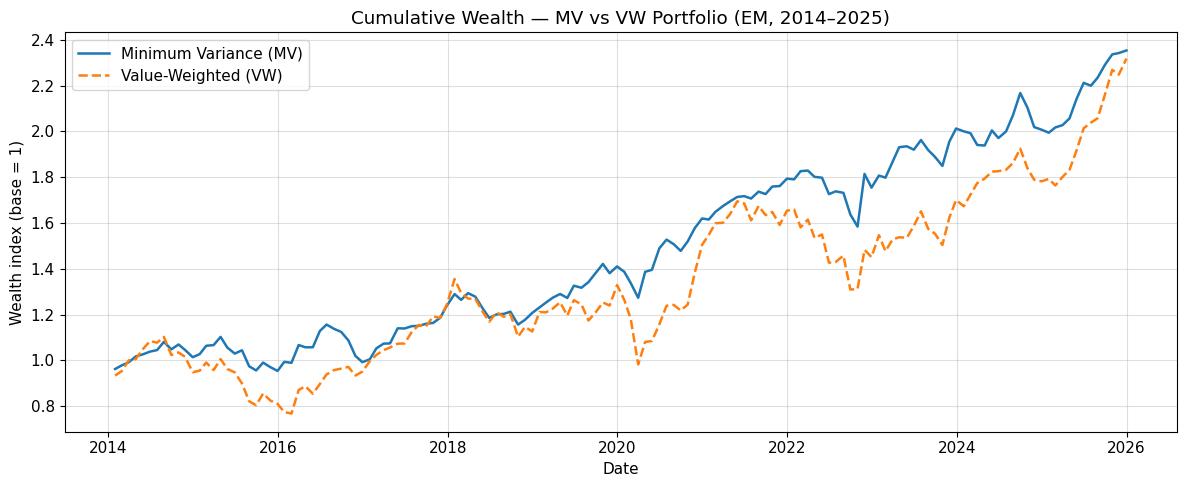

In [14]:
# === Cumulative wealth index (base = 1) ===
cum_mv = (1 + portfolio_returns_mv).cumprod()
cum_vw = (1 + portfolio_returns_vw).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cum_mv.index, cum_mv.values, label="Minimum Variance (MV)", linewidth=1.8)
ax.plot(cum_vw.index, cum_vw.values, label="Value-Weighted (VW)",   linewidth=1.8, linestyle="--")
ax.set_title("Cumulative Wealth — MV vs VW Portfolio (EM, 2014–2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Wealth index (base = 1)")
ax.legend()
plt.tight_layout()

# Save figure before displaying
fig.savefig(OUTPUT_DIR_PLOT / "fig1_cumulative_MV_VW.png", dpi=150)
plt.show()

# === Export performance statistics and monthly returns (Part 1) ===
part_1.to_csv(OUTPUT_DIR_CSV / "stats_part1_MV_VW.csv")

returns_part1 = pd.DataFrame({
    "Return_MV": portfolio_returns_mv,
    "Return_VW": portfolio_returns_vw,})

returns_part1.to_csv(OUTPUT_DIR_CSV / "returns_part1_MV_VW.csv")


---
# Part 2)
---
## 3. Portfolio Allocation with Carbon Emission Reduction
---

### 3.1 Carbon indicators: WACI and carbon footprint



In [15]:
# === Function to get the last available column for a given year Y in an annual dataset ===

'This function will be useful to get date columns for computing divers outputs for the year Y'
def get_year_col(df, Y):

    end_year = pd.Timestamp(f"{Y}-12-31")
    cols = df.columns[df.columns <= end_year]
    
    if len(cols) == 0:
        return None  
    
    return cols.max()  

First, we calculate the carbon intensity, which is necessary to determine the weighted average carbon intensity. 

To do this, we follow these steps:

$$
\text{Emissions}_i = \text{Scope 1}_i + \text{Scope 2}_i
$$

$$
\text{Carbon Intensity}_i = \frac{\text{Emissions}_i}{\text{Revenues}_i}
$$

In [ ]:
# === Compute total annual emissions per firm (Scope 1 + Scope 2) ===
emissions_em = scope_1_em + scope_2_em

# Revenues are reported in thousands USD in the source data. Dividing by 1 000 converts them to millions USD, which is the denomination required for the carbon-intensity formula (tCO2e per million USD revenue).
revenues_musd = revenues_em / 1000

# === Carbon intensity: tCO2e emitted per million USD of revenue ===
ci_full = emissions_em / revenues_musd
print(f"Carbon intensity matrix: {ci_full.shape}  (firms × years)")


Carbon intensity matrix: (668, 27)  (firms × years)


Based on carbon intensity, we can now calculate the weighted average carbon intensity (WACI) for each year:

$$
WACI_Y = \sum_{i=1}^{N} w_{i,Y} \cdot CI_{i,Y}
$$

We achieve this with the function `compute_waci`.

In [17]:
# === Function to compute the Weighted-Average Carbon Intensity (WACI) for a given set of weights ===
def compute_waci(weights, ci_col):
 
    # Keep only assets that have both a positive weight and a valid carbon intensity
    common = weights.index.intersection(ci_col.dropna().index)

    # If there are no assets with valid weights and carbon intensity, return NaN
    if len(common) == 0:
        return np.nan

    # Normalise weights over the common set (handles assets excluded for missing CI)
    w = weights.loc[common]
    w = w / w.sum()

    # WACI is the weighted average of individual carbon intensities
    return float((w * ci_col.loc[common]).sum())


The carbon footprint of the portfolio in year \( Y \) is computed as follows.

The dollar value invested in each asset is:

$$
V_{i,Y} = w_{i,Y} \cdot V_Y
$$

The ownership share of each firm is:


$$
CF_{Y+1} = \frac{1}{V_Y} \sum_{i=1}^{N} \left( \frac{V_{i,Y}}{Cap_{i,Y}} \cdot E_{i,Y} \right)
$$

We compute the carbon footpirnt with the function `compute_carbon_footprint`.


In [18]:
# === Function to compute the CF for year Y ===
def compute_carbon_footprint(weights, emissions_year, market_cap_year, portfolio_value=V0):

    # Keep only assets that have a positive weight, valid emissions data, and valid market cap data
    common = weights.index.intersection(emissions_year.dropna().index).intersection(market_cap_year.dropna().index)

    # If there there is no asset with valid weights and carbon intensity, return NaN
    if len(common) == 0:
        return np.nan
    
    # simplify the notation by attributing the common subset of data to w, E, and cap_usd
    w = weights.loc[common]
    E = emissions_year.loc[common]
    cap_usd = market_cap_year.loc[common] * 1_000_000
    valid = cap_usd > 0
    w, E, cap_usd = w[valid], E[valid], cap_usd[valid]

     # If there there is no asset with valid weights and carbon intensity, return NaN
    if len(w) == 0:
        return np.nan
    
    # Fix the weights to sum to 1 after keeping only the valid assets
    w = w / w.sum()

    # Compute the portfolio value for each asset
    value = w * portfolio_value

    # Compute the ownership share of each asset in the portfolio
    own = value / cap_usd

    # Compute the total emissions owned by the portfolio
    my_emissions = np.sum(own * E)

    # Compute the carbon footprint
    carb_f = my_emissions

    return float(carb_f)


---
### Computing WACI and CF

We now compute WACI and CF for each year with loops. We do it for a MVP and a VW portfolio.

Metrics are attributed to year Y+1 (the holding period) but computed from weights and carbon data available at end of year Y (no look-ahead bias).


In [19]:
# === Carbon Footprint and WACI for the Minimum-Variance portfolio ===
waci_mv, cf_mv = {}, {}

for Y in REB_YEARS:
    weights = weights_mv_by_year[Y]

    # Extract year-Y for each data
    ci_col = ci_full[get_year_col(ci_full, Y)]
    emissions_year = emissions_em[get_year_col(emissions_em, Y)]
    market_cap_year = mc_a_em[get_year_col(mc_a_em, Y)]

    # WACI = weighted average of carbon intensity across portfolio holdings
    waci_mv[Y + 1] = compute_waci(weights, ci_col)

    # CF = tonnes of CO2e attributed to the investor per million USD invested (V0)
    cf_mv[Y + 1] = compute_carbon_footprint(weights, emissions_year, market_cap_year)

waci_mv = pd.Series(waci_mv, name="WACI_MV")
cf_mv = pd.Series(cf_mv,   name="CF_MV")


# === Carbon Footprint and WACI for the Value-Weighted benchmark ===
# The VW benchmark uses annual end-of-year market-cap weights restricted to the same investment set as the MV portfolio so that results are directly comparable.
waci_vw, cf_vw = {}, {}

for Y in REB_YEARS:

    # Get the investment set for year Y (same as for the MV portfolio)
    inv_set, _ = get_investment_set(Y, ret_m_em, ri_m_em, scope_1_em, scope_2_em)                  

    # As previously, we extract year-Y for each data
    ci_col = ci_full[get_year_col(ci_full, Y)]
    emissions_year = emissions_em[get_year_col(emissions_em, Y)]
    market_cap_year = mc_a_em[get_year_col(mc_a_em, Y)]

    # Build VW weights from annual market-cap data restricted to the investment set. We keep only positive market caps to avoid issues with negative or zero weights.
    mc_valid = market_cap_year.loc[market_cap_year.index.intersection(inv_set)].dropna()
    mc_valid = mc_valid[mc_valid > 0]
    weights_vw_y = mc_valid / mc_valid.sum()

    # Compute WACI and CF for the VW benchmark for year Y+1 using the same functions as for the MV portfolio
    waci_vw[Y + 1] = compute_waci(weights_vw_y, ci_col)
    cf_vw[Y + 1] = compute_carbon_footprint(weights_vw_y, emissions_year, market_cap_year)

waci_vw = pd.Series(waci_vw, name="WACI_VW")
cf_vw = pd.Series(cf_vw,   name="CF_VW")


# === Summary table ===
carbon_31 = pd.concat([waci_mv, cf_mv, waci_vw, cf_vw], axis=1)
display(carbon_31)

# === Export ===
carbon_31.to_csv(OUTPUT_DIR_CSV / "carbon_section31_WACI_CF_MV_VW.csv")


,WACI_MV,CF_MV,WACI_VW,CF_VW
2014,302.881413,161.499594,572.006978,463.612318
2015,351.370436,159.459921,630.978574,582.813348
2016,190.375090,103.727267,516.168998,473.136316
2017,270.889871,98.218403,627.970833,717.177842
2018,421.013705,325.650698,700.317049,668.517020
2019,1167.756632,784.946582,483.945267,593.152904
2020,475.718320,227.146865,587.849652,693.722322
2021,430.415461,273.379172,416.320428,676.697790
2022,722.296891,415.698482,422.571687,590.757055
2023,419.960958,597.190622,390.553594,570.249967


---
### Plots for WACI (MV vs VW) and CF (MV vs VW)

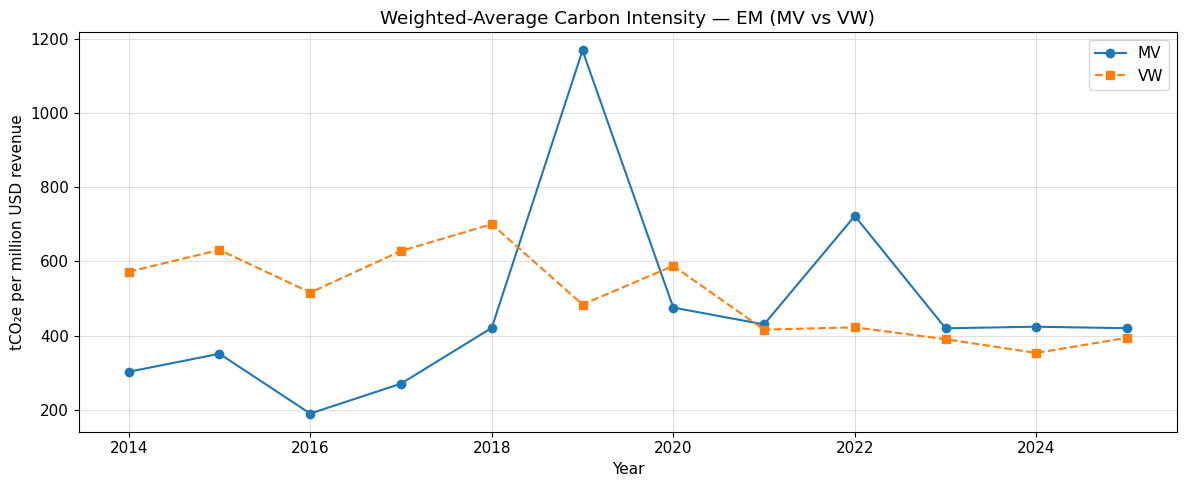

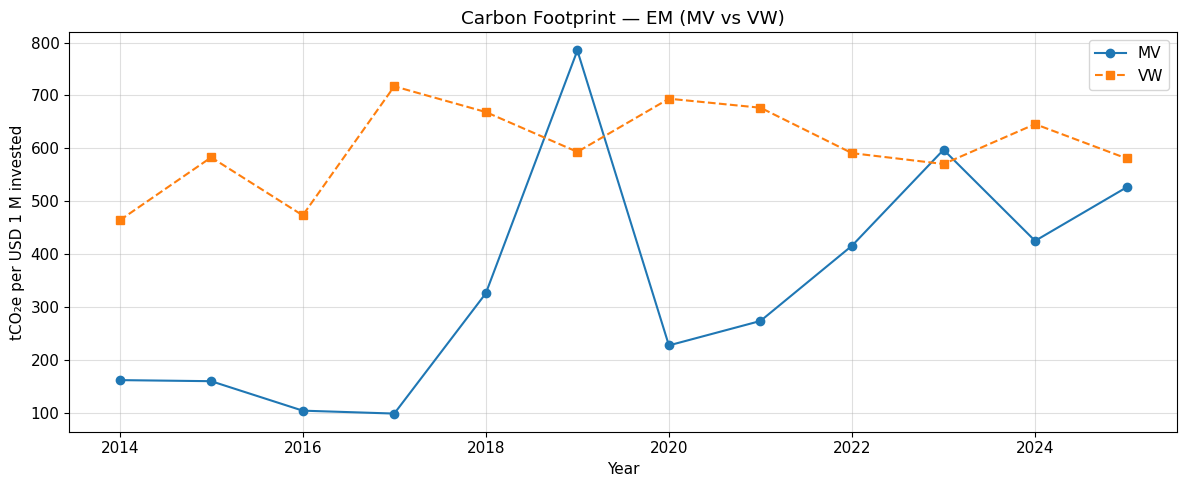

In [20]:
# === Plot 1: Weighted-Average Carbon Intensity (MV vs VW) ===
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(waci_mv.index, waci_mv.values, marker="o", label="MV")
ax.plot(waci_vw.index, waci_vw.values, marker="s", linestyle="--", label="VW")
ax.set_title("Weighted-Average Carbon Intensity — EM (MV vs VW)")
ax.set_xlabel("Year")
ax.set_ylabel("tCO₂e per million USD revenue")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR_PLOT / "fig2_WACI_MV_VW.png", dpi=150)
plt.show()

# === Plot 2: Carbon Footprint (MV vs VW) ===
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cf_mv.index, cf_mv.values, marker="o", label="MV")
ax.plot(cf_vw.index, cf_vw.values, marker="s", linestyle="--", label="VW")
ax.set_title("Carbon Footprint — EM (MV vs VW)")
ax.set_xlabel("Year")
ax.set_ylabel("tCO₂e per USD 1 M invested")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR_PLOT / "fig3_CF_MV_VW.png", dpi=150)
plt.show()



---
# Top 10 contributors for the WACI for 2024

In [21]:
# === Top 10 contributors to the WACI for last rebalancing year (2024) ===
# We rank by this contribution to identify the firms that drive carbon intensity up.

# Settting year and weights for the last rebalancing year (2024)
Y_last = 2024
weights_last = weights_mv_by_year[Y_last]

# Slice the carbon-intensity DataFrame for year 2024
ci_last = ci_full[get_year_col(ci_full, Y_last)]
common = weights_last.index.intersection(ci_last.dropna().index)

# Normalise weights over the common set so contributions sum to the portfolio WACI
w_norm = weights_last.loc[common] / weights_last.loc[common].sum()
ci_contrib = w_norm * ci_last.loc[common]

# Select the top 10 contributors and retrieve company names from the static file
top10_isins = ci_contrib.nlargest(10)
name_col = "Name" if "Name" in firms.columns else ("NAME" if "NAME" in firms.columns else None)
names = firms.reindex(top10_isins.index)[name_col] if name_col else pd.Series("N/A", index=top10_isins.index)

top10_df = pd.DataFrame({
    "ISIN": top10_isins.index,
    "Name": names.values,
    "Weight (%)": (weights_last.reindex(top10_isins.index) * 100).round(4).values,
    "CI (tCO2e/MUSD)": ci_last.reindex(top10_isins.index).round(1).values,
    "WACI contrib": top10_isins.round(4).values,})
display(top10_df)

# Export the top-10 table for use in the report
top10_df.to_csv(OUTPUT_DIR_CSV / "top10_WACI_contributors_2024.csv", index=False)


,ISIN,Name,Weight (%),CI (tCO2e/MUSD),WACI contrib
0,PEP702101002,ENGIE ENERGIA PERU,3.6831,3415.7,125.8033
1,PK0053401011,FAUJI FERTILIZER COMPANY,2.5671,3458.0,88.7703
2,PHY5764J1483,MANILA ELECTRIC,3.2881,1669.8,54.9058
3,CNE1000002S8,COSCO SHIP.EN.TRSP. 'H',3.1546,1283.0,40.4731
4,TW0002412004,CHUNGHWA TELECOM,17.2478,97.1,16.7436
5,PEP700511004,ORYGEN PERU,0.7784,2032.3,15.8203
6,TW0004904008,FAR EASTONE TELECOM.,13.9479,98.4,13.7293
7,PHY751061151,SAN MIGUEL,0.8936,958.8,8.5675
8,INE059A01026,CIPLA,2.6441,308.3,8.1507
9,INE361B01024,DIVIS LABORATORIES,0.8919,762.8,6.8033


---
### 3.2 MV portfolio with −50% carbon-footprint constraint

As in section 2.2, we create a function called `compute_mv_carbon_weights` that calculates the minimum-variance portfolio, incorporating the carbon component. 

In [22]:
def compute_mv_carbon_weights(sigma, valid_assets, emissions_year, market_cap_year, cf_target):

    # Simplify notation and keep only assets with valid emissions and market cap data, and adjust market cap to correct scale
    E = emissions_year.reindex(valid_assets)
    cap_usd = market_cap_year.reindex(valid_assets) * 1_000_000
    ok = E.notna() & cap_usd.notna() & (cap_usd > 0)
    assets = valid_assets[ok]

    # Create filtered versions of the covariance matrix, emissions, and market cap for the assets that have valid data
    sig_filt = sigma.loc[assets, assets]
    E_filt = E.loc[assets]
    cap_filt = cap_usd.loc[assets]
    N = len(assets)

    # Define the portfolio variance function and the carbon constraint function
    def port_var(w): return float(w @ sig_filt.values @ w)
    def carbon_con(w): return cf_target - float(np.sum(w * E_filt.values / cap_filt.values)*1000000)

    # As previous MV optimization but with an additional carbon constraint (type = "ineq" for inequality constraint, and fun = have to return >= 0 when constraint is satisfied)
    constraints = [
        {"type":"eq", "fun": lambda w: np.sum(w) - 1},
        {"type":"ineq", "fun": carbon_con},]
    
    # As previous, bounds between 0 and 1 for each weight, and initial guess with equal weights
    bounds = [(0, 1)] * N
    w0 = np.ones(N) / N

    # As previous, we optimize the portfolio variance with SLSQP method but with the additional carbon constraint
    result = minimize(port_var, 
                      w0,
                      method="SLSQP", 
                      bounds=bounds,
                      constraints=constraints, 
                      options={"ftol": 1e-12, "maxiter": 200})

    return pd.Series(result.x, index=assets)


---
### 3.3 Tracking-Error Minimisation with a 50% Carbon-Footprint Reduction Constraint

The portfolio $P^{(vw)}_{oos}(0.5)$ is constructed to track the value-weighted benchmark as closely as possible while reducing the portfolio carbon footprint by 50%.

The optimisation problem consists of minimising the tracking-error variance:

$$
(\alpha_Y - \alpha_Y^{vw})' \Sigma_Y (\alpha_Y - \alpha_Y^{vw})
$$

subject to:

- a 50% carbon-footprint reduction constraint,
- long-only portfolio weights,
- and the standard portfolio feasibility constraints.

In [23]:
# === Function to compute the TE-minimizing carbon-constrained portfolio weights ===
def compute_te_carbon_weights(sigma, valid_assets, weights_benchmark, emissions_year, market_cap_year, cf_target):

    # Simplify notation and keep only assets with valid emissions and market cap data
    E = emissions_year.reindex(valid_assets)
    cap_usd = market_cap_year.reindex(valid_assets) * 1_000_000
    w_bench = weights_benchmark.reindex(valid_assets).fillna(0)
    ok = E.notna() & cap_usd.notna() & (cap_usd > 0)
    assets = valid_assets[ok]

    # Create filtered versions of the covariance matrix, benchmark weights, emissions, and market cap for the assets that have valid data
    sig_filt = sigma.loc[assets, assets]
    E_filt = E.loc[assets]
    cap_filt = cap_usd.loc[assets]
    w_b = w_bench.loc[assets]
    w_b = w_b / w_b.sum()
    N = len(assets)

    # Define the tracking error function to minimize and the carbon constraint function
    def te_obj(w):
        diff = w - w_b.values
        return float(diff @ sig_filt.values @ diff)
    def carbon_con(w): return cf_target - float(np.sum(w * E_filt.values / cap_filt.values)*1000000)

    # Same constraints and bounds as in the carbon-constrained MV optimization, but with the tracking error objective function
    constraints = [
        {"type":"eq","fun": lambda w: np.sum(w) - 1},
        {"type":"ineq","fun": carbon_con},]

    bounds = [(0, 1)] * N

    # Initial guess: we can start from the benchmark weights, which is a common choice for tracking error optimization problems
    result = minimize(te_obj, 
                      w_b.values, 
                      method="SLSQP", 
                      bounds=bounds,
                      constraints=constraints, 
                      options={"ftol": 1e-12, "maxiter": 200})

    return pd.Series(result.x, index=assets)

---
### 3.4 Comparison of portfolios (Statistics and Plots)

The tables and figures allow us to compare the four portfolios $P^{(mv)}_{oos}$, $P^{(mv)}_{oos}(0.5)$, $P^{(vw)}_{oos}$, and $P^{(vw)}_{oos}(0.5)$.


In [24]:
# Create dictionaries to store the results for the carbon-constrained portfolios
weights_mv_50_by_year, waci_mv_50, cf_mv_50 = {}, {}, {}
weights_vw_50_by_year, waci_vw_50, cf_vw_50 = {}, {}, {}

# Loop as in the previous sections, but we add the carbon constraints of 50% reduction in CF compared to the unconstrained MV and VW portfolios, respectively.
for Y in REB_YEARS:

    # Rebuild the investment set and covariance matrix for year Y
    inv_set, ret_window = get_investment_set(Y, ret_m_em, ri_m_em, scope_1_em, scope_2_em)
    mu, sigma, valid_assets, N = compute_matrix(ret_window, inv_set)

    # Extract the annual carbon and market-cap columns for year Y (same for both portfolios since they use the same investment set)
    ci_col = ci_full[get_year_col(ci_full, Y)]
    emissions_year = emissions_em[get_year_col(emissions_em, Y)]
    market_cap_year = mc_a_em[get_year_col(mc_a_em, Y)]

    # ── P_mv(0.5): minimise portfolio variance subject to CF ≤ 0.5 × CF_mv ──
    w_mv50 = compute_mv_carbon_weights(sigma, valid_assets, emissions_year, market_cap_year, 0.5 * cf_mv[Y + 1])

    # Store the weights, the WACI, and the CF for each year Y+1 for MVP
    weights_mv_50_by_year[Y] = w_mv50
    waci_mv_50[Y + 1] = compute_waci(w_mv50, ci_col)
    cf_mv_50[Y + 1] = compute_carbon_footprint(w_mv50, emissions_year, market_cap_year)

    # compute the weight of VW benchmark with the carbon constraint of 50% reduction in CF compared to the unconstrained VW portfolio
    w_vw50 = compute_te_carbon_weights(sigma, valid_assets, weights_vw_by_year[Y], emissions_year, market_cap_year, 0.5 * cf_vw[Y + 1])

    # Store the weights, the WACI, and the CF for each year Y+1 for VW
    weights_vw_50_by_year[Y] = w_vw50
    waci_vw_50[Y + 1] = compute_waci(w_vw50, ci_col)
    cf_vw_50[Y + 1] = compute_carbon_footprint(w_vw50, emissions_year, market_cap_year)

# === Backtest both carbon-constrained portfolios ===
portfolio_returns_mv_50 = backtest(weights_mv_50_by_year, ret_m_em)
portfolio_returns_vw_50 = backtest(weights_vw_50_by_year, ret_m_em)

waci_mv_50 = pd.Series(waci_mv_50, name="WACI_MV_50")
cf_mv_50 = pd.Series(cf_mv_50, name="CF_MV_50")
waci_vw_50 = pd.Series(waci_vw_50, name="WACI_VW_50")
cf_vw_50 = pd.Series(cf_vw_50, name="CF_VW_50")

# === Summary statistics for Sections 3.2 and 3.3 ===
stats_part3 = pd.concat([
    portfolio_stats(portfolio_returns_mv, rf).rename("MVP"),
    portfolio_stats(portfolio_returns_mv_50, rf).rename("MVP −50% CF"),
    portfolio_stats(portfolio_returns_vw, rf).rename("VW"),
    portfolio_stats(portfolio_returns_vw_50, rf).rename("VW −50% CF"),], axis=1)
display(stats_part3)

# Save performance statistics
stats_part3.to_csv(OUTPUT_DIR_CSV / "stats_part3_carbon_constrained.csv")


,MVP,MVP −50% CF,VW,VW −50% CF
Ann. avg return,0.076865,0.073755,0.082412,0.125076
Ann. volatility,0.103991,0.101421,0.155448,0.181440
Sharpe ratio,0.571218,0.555150,0.418341,0.594154
Min monthly ret,-0.067043,-0.069017,-0.167734,-0.214163
Max monthly ret,0.145186,0.129122,0.134078,0.153834


Plots and Statistics

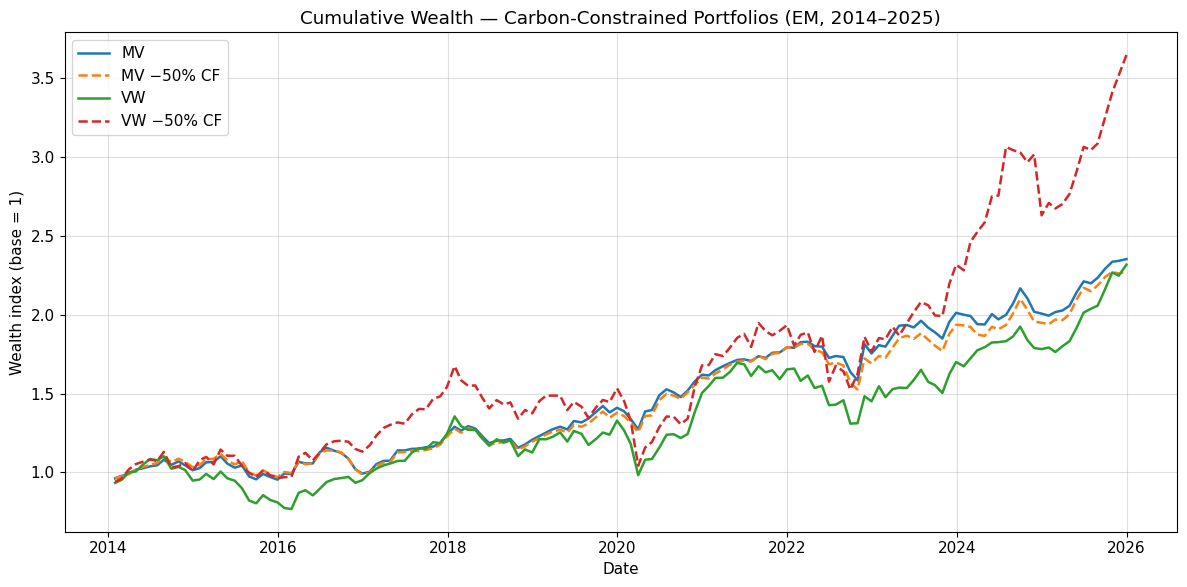

,WACI_MV,WACI_MV_50,WACI_VW,WACI_VW_50,CF_MV,CF_MV_50,CF_VW,CF_VW_50
2014,302.881413,196.916079,572.006978,321.628952,161.499594,80.749797,463.612318,144.179082
2015,351.370436,204.895215,630.978574,286.679323,159.459921,79.729961,582.813348,291.406674
2016,190.375090,145.249149,516.168998,218.086188,103.727267,51.863634,473.136316,236.568158
2017,270.889871,117.529205,627.970833,292.063630,98.218403,49.109201,717.177842,358.588921
2018,421.013705,389.316366,700.317049,642.135691,325.650698,162.825349,668.517020,334.258510
2019,1167.756632,947.777931,483.945267,272.431770,784.946582,392.473291,593.152904,296.576452
2020,475.718320,241.917093,587.849652,320.750462,227.146865,113.573432,693.722322,346.861161
2021,430.415461,333.694872,416.320428,298.570913,273.379172,136.689586,676.697790,338.348895
2022,722.296891,555.447969,422.571687,263.944556,415.698482,207.849241,590.757055,295.378527
2023,419.960958,262.489212,390.553594,300.549430,597.190622,298.595311,570.249967,285.124984


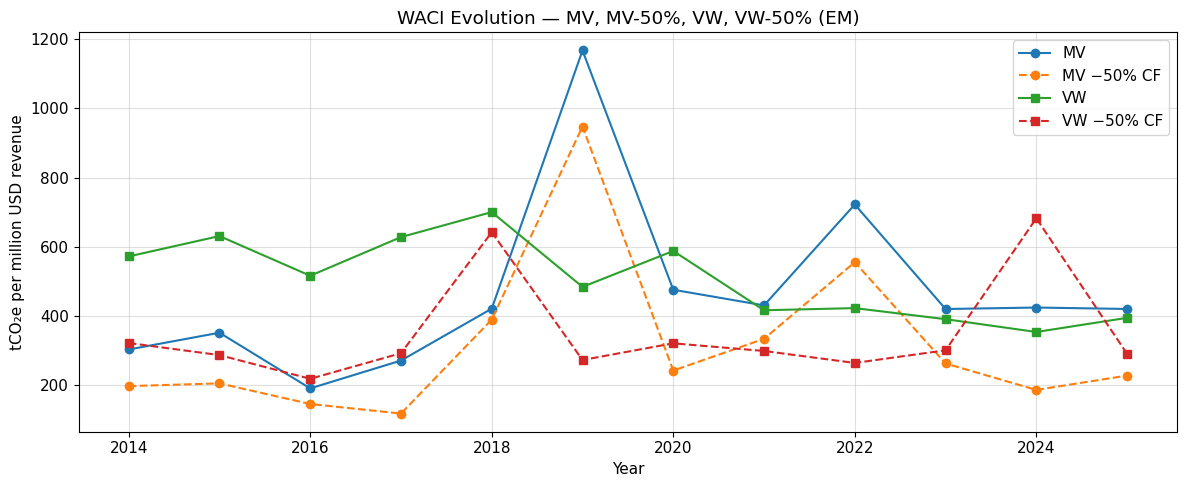

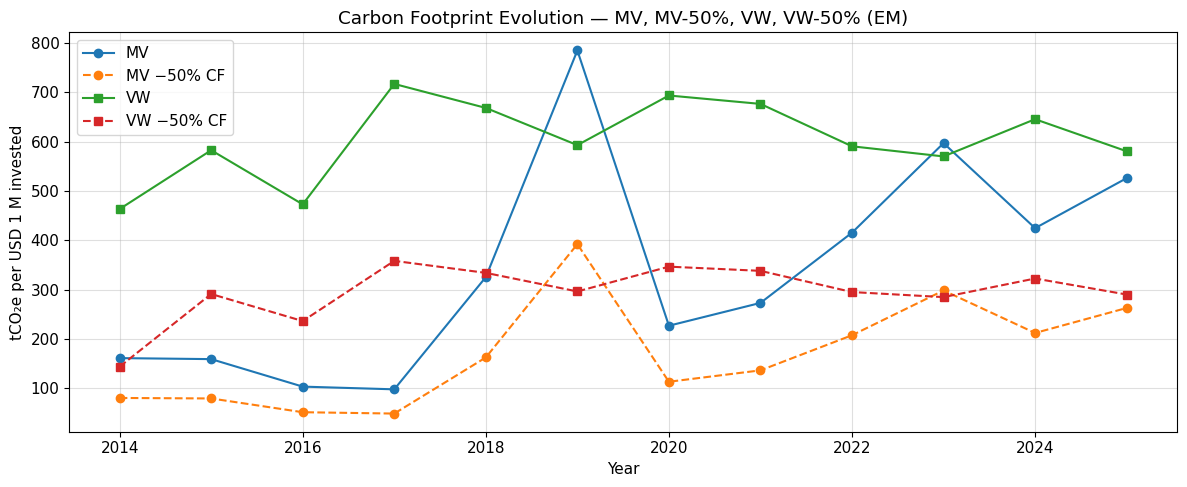

In [25]:
# === Cumulative wealth — MV, MV-50%, VW, VW-50% (Section 3.2 / 3.3) ===
cum_mv = (1 + portfolio_returns_mv).cumprod()
cum_mv_50 = (1 + portfolio_returns_mv_50).cumprod()
cum_vw = (1 + portfolio_returns_vw).cumprod()
cum_vw_50 = (1 + portfolio_returns_vw_50).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cum_mv.index, cum_mv.values, label="MV", linewidth=1.8)
ax.plot(cum_mv_50.index, cum_mv_50.values, label="MV −50% CF", linewidth=1.8, linestyle="--")
ax.plot(cum_vw.index, cum_vw.values, label="VW", linewidth=1.8)
ax.plot(cum_vw_50.index, cum_vw_50.values, label="VW −50% CF", linewidth=1.8, linestyle="--", color="tab:red")
ax.set_title("Cumulative Wealth — Carbon-Constrained Portfolios (EM, 2014–2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Wealth index (base = 1)")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR_PLOT / "fig4_cumulative_carbon_constrained.png", dpi=150)
plt.show()

# === Carbon metrics table (all four portfolios) ===
carbon_part3 = pd.concat([waci_mv, waci_mv_50, waci_vw, waci_vw_50, cf_mv,   cf_mv_50,   cf_vw,   cf_vw_50], axis=1)
display(carbon_part3)

# === Plot WACI evolution — Section 3 ===
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(waci_mv.index, waci_mv.values, marker="o", label="MV")
ax.plot(waci_mv_50.index, waci_mv_50.values, marker="o", linestyle="--", label="MV −50% CF")
ax.plot(waci_vw.index, waci_vw.values, marker="s", label="VW")
ax.plot(waci_vw_50.index, waci_vw_50.values, marker="s", linestyle="--", label="VW −50% CF")
ax.set_title("WACI Evolution — MV, MV-50%, VW, VW-50% (EM)")
ax.set_xlabel("Year")
ax.set_ylabel("tCO₂e per million USD revenue")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR_PLOT / "fig5_WACI_carbon_constrained.png", dpi=150)
plt.show()

# === Plot Carbon Footprint evolution — Section 3 ===
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cf_mv.index, cf_mv.values, marker="o", label="MV")
ax.plot(cf_mv_50.index, cf_mv_50.values, marker="o", linestyle="--", label="MV −50% CF")
ax.plot(cf_vw.index, cf_vw.values, marker="s", label="VW")
ax.plot(cf_vw_50.index, cf_vw_50.values, marker="s", linestyle="--", label="VW −50% CF")
ax.set_title("Carbon Footprint Evolution — MV, MV-50%, VW, VW-50% (EM)")
ax.set_xlabel("Year")
ax.set_ylabel("tCO₂e per USD 1 M invested")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR_PLOT / "fig6_CF_carbon_constrained.png", dpi=150)
plt.show()

# === Export carbon table and monthly returns ===
carbon_part3.to_csv(OUTPUT_DIR_CSV / "carbon_part3_all_portfolios.csv")

returns_part3 = pd.DataFrame({
    "Return_MV": portfolio_returns_mv,
    "Return_MV_50": portfolio_returns_mv_50,
    "Return_VW": portfolio_returns_vw,
    "Return_VW_50": portfolio_returns_vw_50,})

returns_part3.to_csv(OUTPUT_DIR_CSV / "returns_part3_all.csv")



---
## 4. Net-Zero Portfolio
---
### 4.1 Net-Zero portfolio: tracking-error minimisation with a declining carbon-footprint constraint

The net-zero constraint tightens each year from the initial VW carbon footprint:
$CF_Y^{(p)}\leq(1-\theta)^{Y-Y_0+1}CF_{Y_0}^{VW}$ with $\theta=10\%$.

In [26]:

Y0 = 2013
cf_vw_Y0 = cf_vw[Y0 + 1]   # VW carbon footprint in the first holding year (2014)
print(f"VW carbon footprint at Y0 = 2013: {cf_vw_Y0:.6e} tCO2e per USD invested")

weights_nz_by_year, waci_nz, cf_nz = {}, {}, {}

for Y in REB_YEARS:

    # Rebuild the investment set and covariance matrix for year Y
    inv_set, ret_window = get_investment_set(Y, ret_m_em, ri_m_em, scope_1_em, scope_2_em)
    mu, sigma, valid_assets, N = compute_matrix(ret_window, inv_set)

    # Extract the annual carbon and market-cap columns for year Y
    ci_col = ci_full[get_year_col(ci_full, Y)]
    emissions_year = emissions_em[get_year_col(emissions_em, Y)]
    market_cap_year = mc_a_em[get_year_col(mc_a_em, Y)]

    # Compute the net-zero carbon-footprint target for year Y. The exponent counts the number of annual decarbonisation steps since Y0
    exponent  = Y - Y0 + 1
    cf_target = (1 - THETA_NZ) ** exponent * cf_vw_Y0

    print(f"Y={Y}  exponent={exponent}  cf_target={cf_target:.4e}  cf_vw={cf_vw[Y+1]:.4e}")

    # Minimise tracking error relative to the VW benchmark subject to the net-zero CF target
    w_nz = compute_te_carbon_weights(sigma, valid_assets, weights_vw_by_year[Y], emissions_year, market_cap_year, cf_target)
    weights_nz_by_year[Y] = w_nz
    waci_nz[Y + 1] = compute_waci(w_nz, ci_col)
    cf_nz[Y + 1] = compute_carbon_footprint(w_nz, emissions_year, market_cap_year)

# Backtest the net-zero portfolio
portfolio_returns_nz = backtest(weights_nz_by_year, ret_m_em)
waci_nz = pd.Series(waci_nz, name="WACI_NZ")
cf_nz = pd.Series(cf_nz, name="CF_NZ")

print(f"Net-Zero return series: {portfolio_returns_nz.shape[0]} months")


VW carbon footprint at Y0 = 2013: 4.636123e+02 tCO2e per USD invested
Y=2013  exponent=1  cf_target=4.1725e+02  cf_vw=4.6361e+02
Y=2014  exponent=2  cf_target=3.7553e+02  cf_vw=5.8281e+02
Y=2015  exponent=3  cf_target=3.3797e+02  cf_vw=4.7314e+02
Y=2016  exponent=4  cf_target=3.0418e+02  cf_vw=7.1718e+02
Y=2017  exponent=5  cf_target=2.7376e+02  cf_vw=6.6852e+02
Y=2018  exponent=6  cf_target=2.4638e+02  cf_vw=5.9315e+02
Y=2019  exponent=7  cf_target=2.2174e+02  cf_vw=6.9372e+02
Y=2020  exponent=8  cf_target=1.9957e+02  cf_vw=6.7670e+02
Y=2021  exponent=9  cf_target=1.7961e+02  cf_vw=5.9076e+02
Y=2022  exponent=10  cf_target=1.6165e+02  cf_vw=5.7025e+02
Y=2023  exponent=11  cf_target=1.4549e+02  cf_vw=6.4568e+02
Y=2024  exponent=12  cf_target=1.3094e+02  cf_vw=5.8074e+02
Net-Zero return series: 144 months


---
### 4.2 Comparison of portfolios

We now compare the three passive portfolios: the unconstrained VW benchmark $P^{(vw)}_{oos}$, the static 50% reduction portfolio $P^{(vw)}_{oos}(0.5)$, and the net-zero glide-path portfolio $P^{(vw)}_{oos}(NZ)$.


,VW,VW −50% CF,VW Net-Zero
Ann. avg return,0.082412,0.125076,0.120440
Ann. volatility,0.155448,0.181440,0.189301
Sharpe ratio,0.418341,0.594154,0.544987
Min monthly ret,-0.167734,-0.214163,-0.216264
Max monthly ret,0.134078,0.153834,0.150517


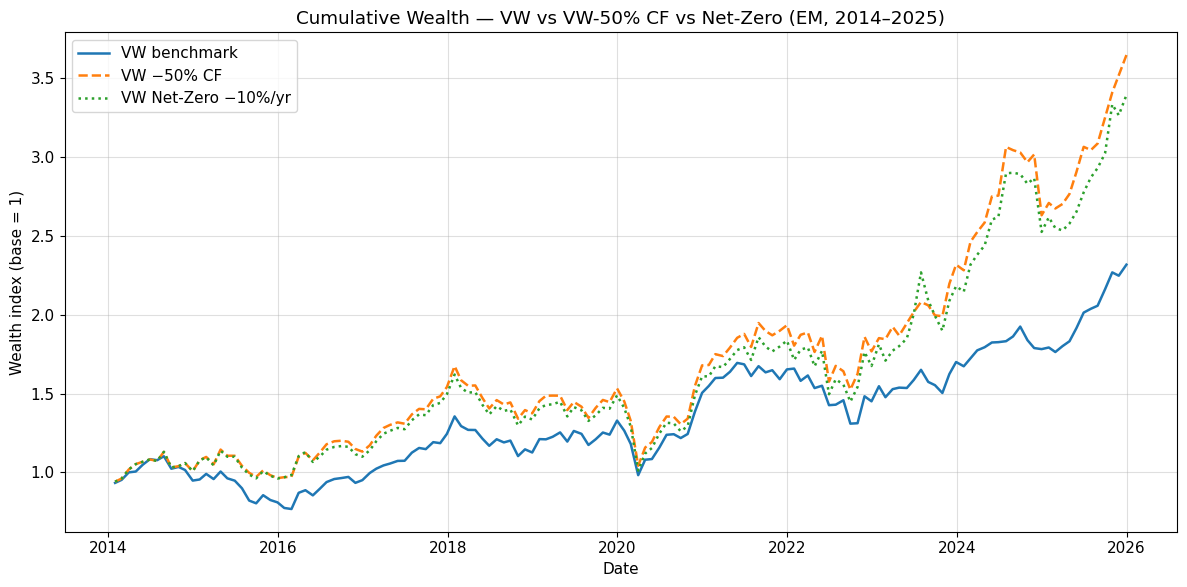

In [27]:
# === Summary statistics for Section 4.2 ===
stats_part4 = pd.concat([
    portfolio_stats(portfolio_returns_vw, rf).rename("VW"),
    portfolio_stats(portfolio_returns_vw_50, rf).rename("VW −50% CF"),
    portfolio_stats(portfolio_returns_nz, rf).rename("VW Net-Zero"),], axis=1)
display(stats_part4)

# Save performance statistics
stats_part4.to_csv(OUTPUT_DIR_CSV / "stats_part4_netzero.csv")

# === Cumulative wealth — VW, VW-50%, Net-Zero ===
cum_nz = (1 + portfolio_returns_nz).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cum_vw.index, cum_vw.values, label="VW benchmark", linewidth=1.8)
ax.plot(cum_vw_50.index, cum_vw_50.values, label="VW −50% CF", linewidth=1.8, linestyle="--")
ax.plot(cum_nz.index, cum_nz.values, label="VW Net-Zero −10%/yr", linewidth=1.8, linestyle=":")
ax.set_title("Cumulative Wealth — VW vs VW-50% CF vs Net-Zero (EM, 2014–2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Wealth index (base = 1)")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR_PLOT / "fig7_cumulative_netzero.png", dpi=150)
plt.show()


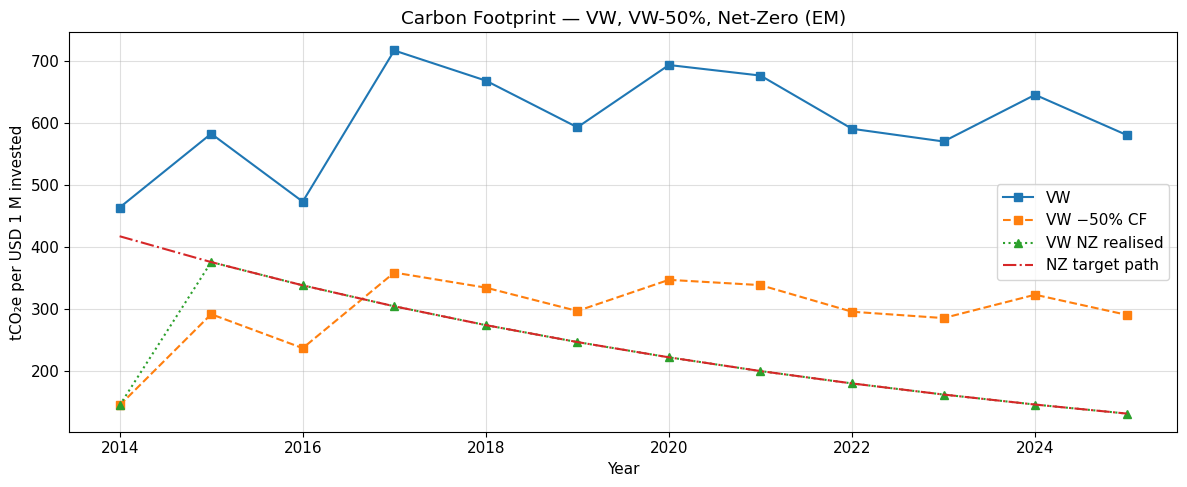

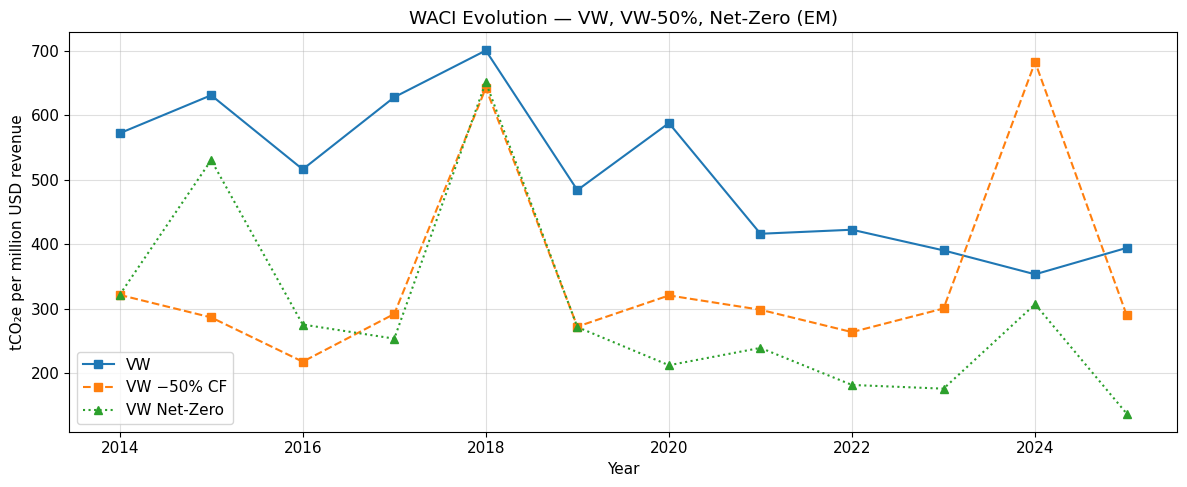

,WACI_VW,WACI_VW_50,WACI_NZ,CF_VW,CF_VW_50,CF_NZ
2014,572.006978,321.628952,321.583401,463.612318,144.179082,144.159322
2015,630.978574,286.679323,530.459784,582.813348,291.406674,375.525977
2016,516.168998,218.086188,275.648051,473.136316,236.568158,337.973380
2017,627.970833,292.063630,253.792862,717.177842,358.588921,304.176042
2018,700.317049,642.135691,651.121259,668.517020,334.258510,273.758437
2019,483.945267,272.431770,271.702312,593.152904,296.576452,246.382594
2020,587.849652,320.750462,212.602508,693.722322,346.861161,221.744334
2021,416.320428,298.570913,239.453906,676.697790,338.348895,199.569901
2022,422.571687,263.944556,182.033844,590.757055,295.378527,179.612911
2023,390.553594,300.549430,176.285696,570.249967,285.124984,161.651620


,MV,MV −50% CF,VW,VW −50% CF,VW Net-Zero
Ann. avg return,0.076865,0.073755,0.082412,0.125076,0.120440
Ann. volatility,0.103991,0.101421,0.155448,0.181440,0.189301
Sharpe ratio,0.571218,0.555150,0.418341,0.594154,0.544987
Min monthly ret,-0.067043,-0.069017,-0.167734,-0.214163,-0.216264
Max monthly ret,0.145186,0.129122,0.134078,0.153834,0.150517


In [28]:
# === Net-zero glide path and realised carbon footprints ===
nz_path = pd.Series({Y + 1: (1 - THETA_NZ) ** (Y - Y0 + 1) * cf_vw_Y0 for Y in REB_YEARS}, name="NZ target path")

# === Plot carbon footprint evolution with the net-zero target path ===
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cf_vw.index, cf_vw.values, marker="s", label="VW")
ax.plot(cf_vw_50.index, cf_vw_50.values, marker="s", linestyle="--", label="VW −50% CF")
ax.plot(cf_nz.index, cf_nz.values, marker="^", linestyle=":", label="VW NZ realised")
ax.plot(nz_path.index, nz_path.values, linestyle="-.", label="NZ target path")
ax.set_title("Carbon Footprint — VW, VW-50%, Net-Zero (EM)")
ax.set_xlabel("Year")
ax.set_ylabel("tCO₂e per USD 1 M invested")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR_PLOT / "fig8_CF_netzero_path.png", dpi=150)
plt.show()

# === WACI evolution — all passive portfolios ===
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(waci_vw.index, waci_vw.values, marker="s", label="VW")
ax.plot(waci_vw_50.index, waci_vw_50.values, marker="s", linestyle="--", label="VW −50% CF")
ax.plot(waci_nz.index, waci_nz.values, marker="^", linestyle=":", label="VW Net-Zero")
ax.set_title("WACI Evolution — VW, VW-50%, Net-Zero (EM)")
ax.set_xlabel("Year")
ax.set_ylabel("tCO₂e per million USD revenue")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR_PLOT / "fig9_WACI_netzero.png", dpi=150)
plt.show()

# === Carbon metrics table ===
carbon_part4 = pd.concat([waci_vw, waci_vw_50, waci_nz, cf_vw, cf_vw_50, cf_nz], axis=1)
display(carbon_part4)

# === Export all remaining results ===
carbon_part4.to_csv(OUTPUT_DIR_CSV / "carbon_part4_netzero.csv")

returns_part4 = pd.DataFrame({
    "Return_VW": portfolio_returns_vw,
    "Return_VW_50": portfolio_returns_vw_50,
    "Return_NZ": portfolio_returns_nz,})
    
returns_part4.to_csv(OUTPUT_DIR_CSV / "returns_part4_netzero.csv")

# === Consolidated results export ===
# All portfolio statistics in a single table
all_stats = pd.concat([
    portfolio_stats(portfolio_returns_mv, rf).rename("MV"),
    portfolio_stats(portfolio_returns_mv_50, rf).rename("MV −50% CF"),
    portfolio_stats(portfolio_returns_vw, rf).rename("VW"),
    portfolio_stats(portfolio_returns_vw_50, rf).rename("VW −50% CF"),
    portfolio_stats(portfolio_returns_nz, rf).rename("VW Net-Zero"),], axis=1)
all_stats.to_csv(OUTPUT_DIR_CSV / "stats_all_portfolios.csv")

# All carbon metrics in a single table
all_carbon = pd.concat([waci_mv, waci_mv_50, waci_vw, waci_vw_50, waci_nz, cf_mv,   cf_mv_50,   cf_vw,   cf_vw_50,   cf_nz], axis=1)
all_carbon.to_csv(OUTPUT_DIR_CSV / "carbon_all_portfolios.csv")

display(all_stats)
